In [16]:
# 📦 Schritt 1: Bibliotheken importieren
import pandas as pd
import glob
import os

# 📁 Schritt 2: Pfad zu den Metrics-Dateien definieren
folder_path = "/Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solutions_TPSA/"
file_pattern = os.path.join(folder_path, "Metrics_*.csv")

# 📂 Schritt 3: Alle passenden CSV-Dateien finden
file_list = glob.glob(file_pattern)
print(f"{len(file_list)} Dateien gefunden.")

# 📊 Schritt 4: Alle Dateien einlesen und zusammenfügen
all_dfs = [pd.read_csv(file) for file in file_list]
full_df = pd.concat(all_dfs, ignore_index=True)
print("Daten erfolgreich zusammengeführt.")
display(full_df.head())

# 📈 Schritt 5: Durchschnittswerte pro Instanz + Algorithmus berechnen
average_df = full_df.groupby(["Instance", "Algorithm"], as_index=False).mean()
print("Durchschnittswerte berechnet.")
display(average_df.head())

# 💾 Schritt 6: Ergebnis abspeichern
output_path = os.path.join(folder_path, "Metrics_averaged.csv")
average_df.to_csv(output_path, index=False)
print(f"Aggregierte Datei gespeichert unter: {output_path}")

13 Dateien gefunden.
Daten erfolgreich zusammengeführt.


,Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
0,a3_o80_m10_an10_ar9_reduced,PSA,238.59,0.377604,0.955699,0.667233,0.110728,16.981132,0.184208,0.480735
1,a3_o80_m10_an10_ar9_reduced,DBSA,67.81,0.684896,0.168514,0.588334,0.318641,23.899371,0.041178,0.553624
2,a3_o80_m10_an10_ar9_reduced,TPSA,118.75,0.880208,0.205979,0.682425,0.101393,59.119497,0.075372,0.714286
3,a5_o96_m10_an10_ar10_reduced,PSA,184.62,0.557143,0.323478,0.247524,0.267650,25.414365,0.072448,0.629529
4,a5_o96_m10_an10_ar10_reduced,DBSA,60.19,0.492857,0.234444,0.185769,0.347054,22.651934,0.065636,0.632020


Durchschnittswerte berechnet.


,Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
0,a10_o107_m5_an57_ar12,DBSA,63.325000,0.670641,0.203238,0.264170,0.271254,34.504242,0.038637,0.498015
1,a10_o107_m5_an57_ar12,PSA,153.335833,0.412648,0.757338,0.232367,0.213412,17.606923,0.048669,0.454504
2,a10_o107_m5_an57_ar12,TPSA,78.135000,0.789513,0.145052,0.261807,0.148060,47.888835,0.038516,0.698173
3,a10_o114_m6_an57_ar11,DBSA,82.684167,0.729419,0.157769,0.276564,0.180892,33.011086,0.067745,0.808222
4,a10_o114_m6_an57_ar11,PSA,329.575833,0.383952,0.576767,0.372830,0.127878,15.450667,0.107523,0.810583


Aggregierte Datei gespeichert unter: /Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solutions_TPSA/Metrics_averaged.csv


In [17]:
import pandas as pd

# Datei einlesen (Pfad ggf. anpassen, falls Datei woanders liegt)
df = pd.read_csv("Metrics_averaged.csv")

# Rundung zur besseren Lesbarkeit (optional)
df_rounded = df.round(3)

# Ausgabe als DataFrame mit schöner Formatierung
from IPython.display import display, HTML
display(HTML(df_rounded.to_html(index=False)))

Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
a10_o107_m5_an57_ar12,DBSA,63.325,0.671,0.203,0.264,0.271,34.504,0.039,0.498
a10_o107_m5_an57_ar12,PSA,153.336,0.413,0.757,0.232,0.213,17.607,0.049,0.455
a10_o107_m5_an57_ar12,TPSA,78.135,0.790,0.145,0.262,0.148,47.889,0.039,0.698
a10_o114_m6_an57_ar11,DBSA,82.684,0.729,0.158,0.277,0.181,33.011,0.068,0.808
a10_o114_m6_an57_ar11,PSA,329.576,0.384,0.577,0.373,0.128,15.451,0.108,0.811
a10_o114_m6_an57_ar11,TPSA,116.965,0.847,0.128,0.291,0.118,51.538,0.072,0.954
a10_o128_m6_an51_ar13,DBSA,72.071,0.740,0.234,0.004,0.257,32.949,0.051,0.822
a10_o128_m6_an51_ar13,PSA,212.473,0.386,0.584,0.004,0.249,13.586,0.095,0.858
a10_o128_m6_an51_ar13,TPSA,105.163,0.868,0.178,0.004,0.153,53.465,0.049,0.959
a10_o144_m6_an53_ar12,DBSA,53.752,0.568,0.198,0.423,0.278,26.035,0.062,0.540


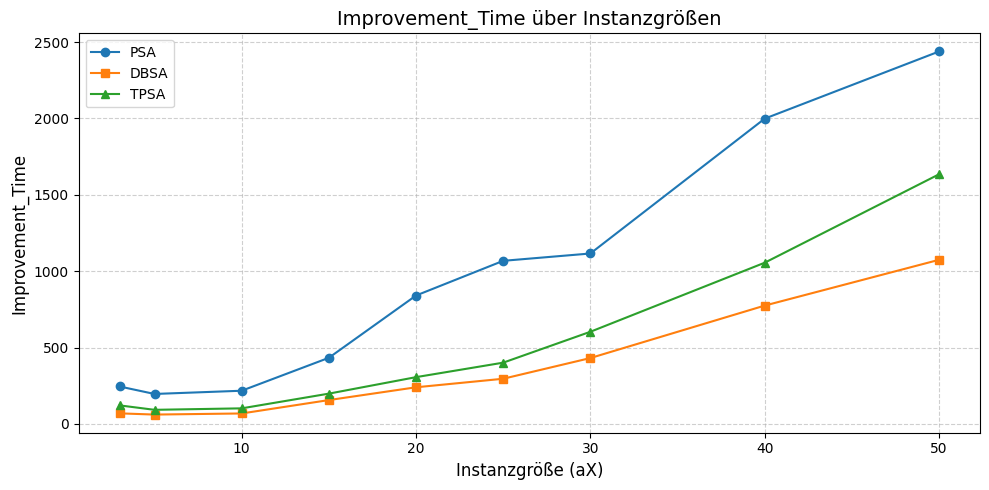

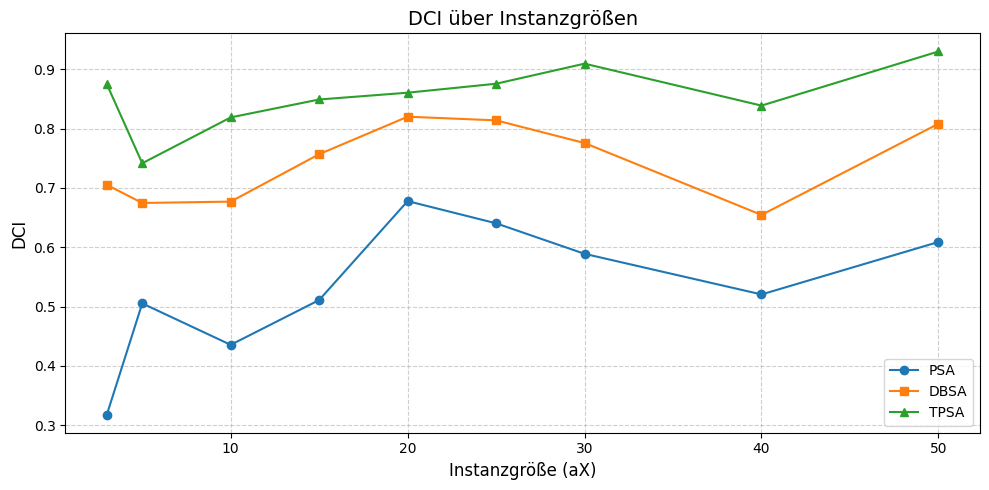

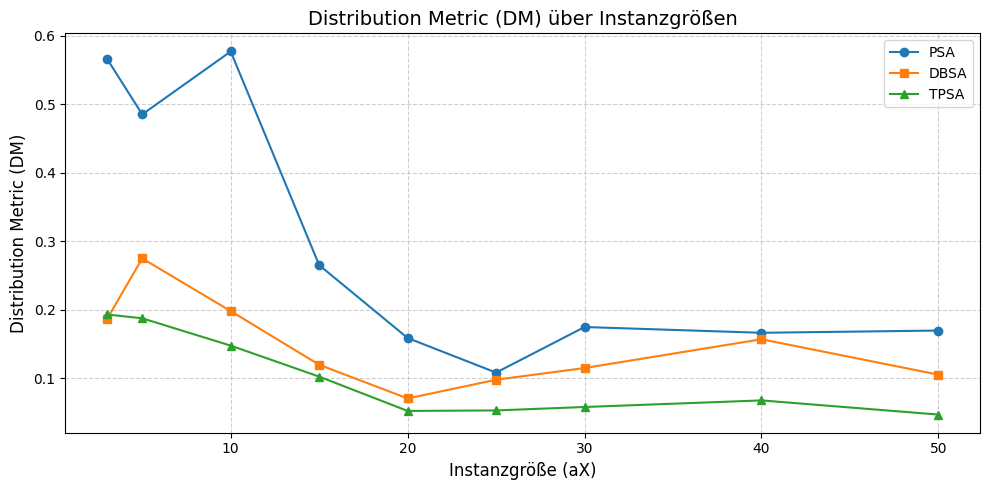

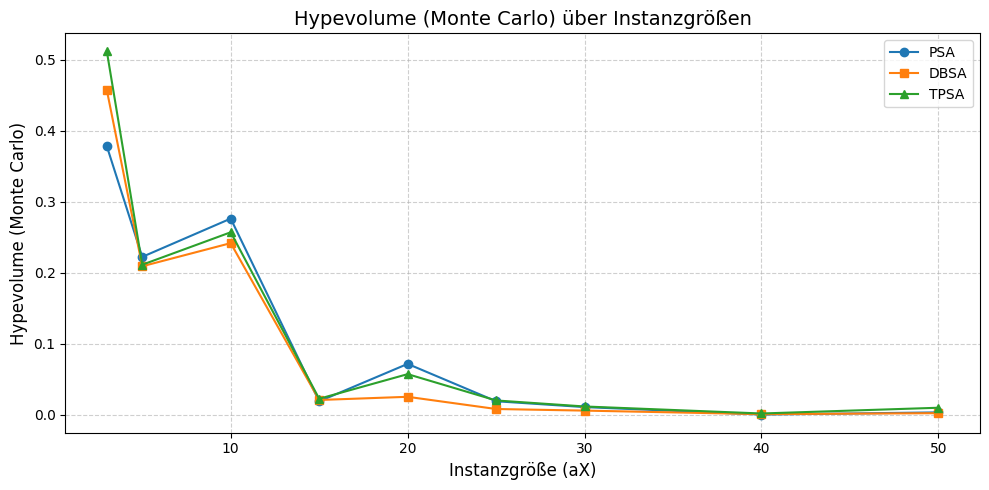

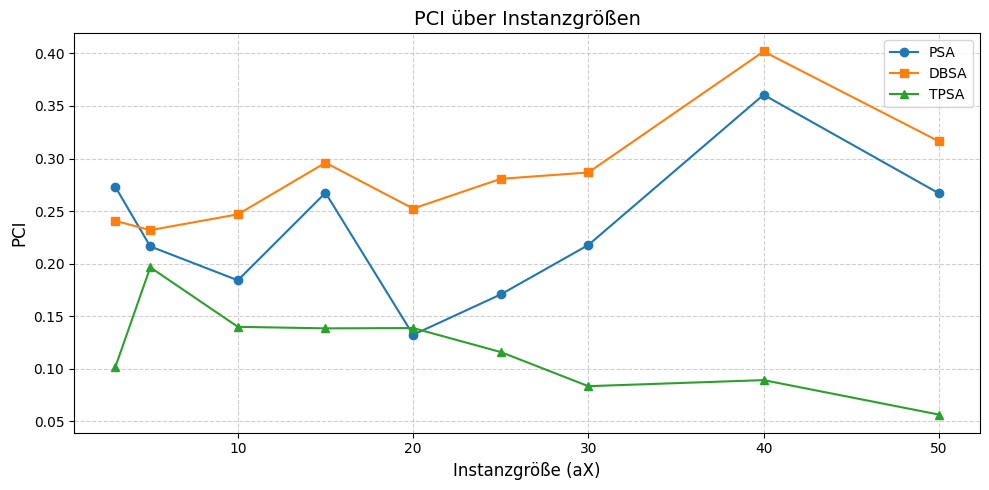

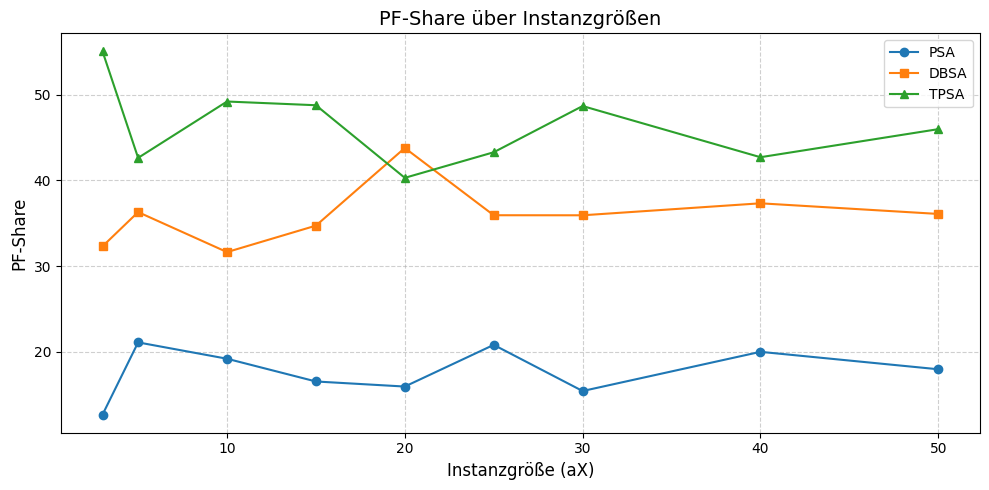

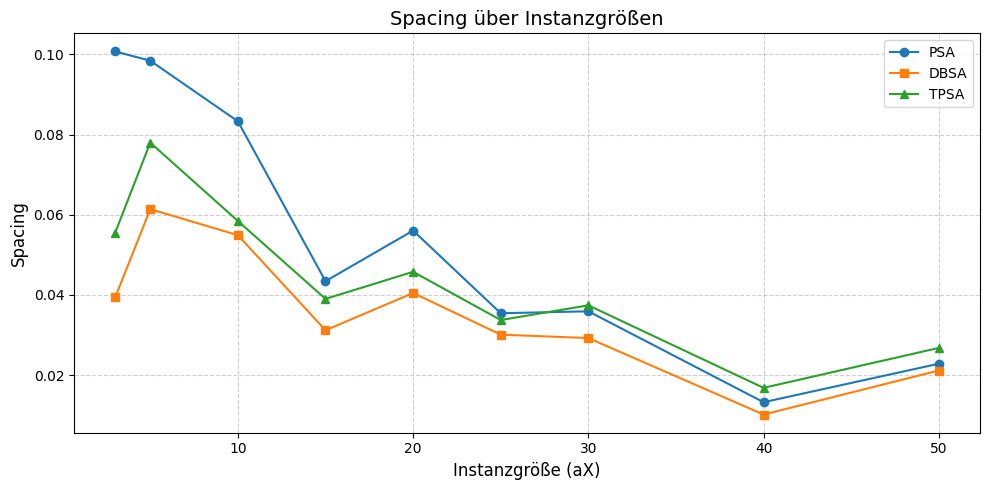

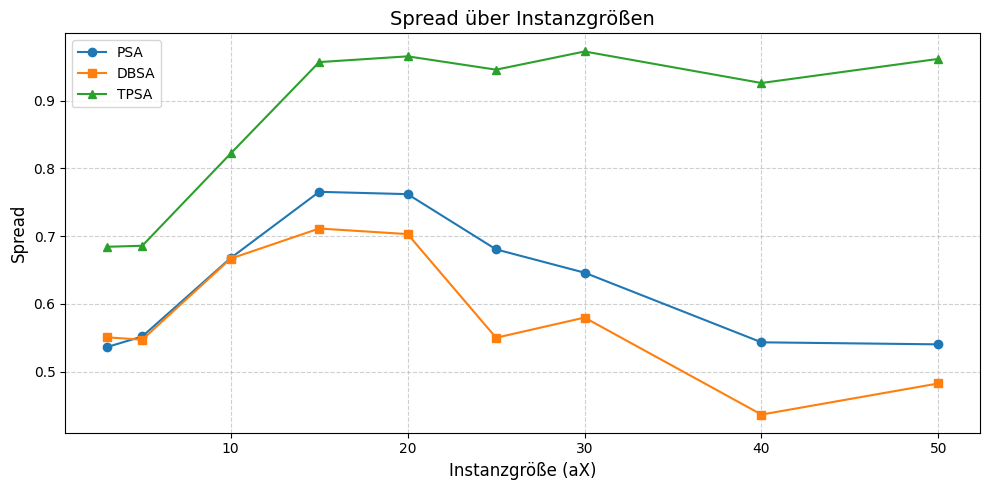

In [18]:
# 📦 Imports
import pandas as pd
import matplotlib.pyplot as plt

# 📂 Datei einlesen
file_path = "/Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solutions_TPSA/Metrics_averaged.csv"
df = pd.read_csv(file_path)

# 🔍 Instanzgröße extrahieren (z. B. 'a3_o80' → 3)
df["Instance_Size"] = df["Instance"].str.extract(r"a(\d+)_").astype(int)

# 🧹 Metriken auswählen (alle außer 'Instance', 'Algorithm', 'Instance_Size')
metrics = [col for col in df.columns if col not in ["Instance", "Algorithm", "Instance_Size"]]

# 🧮 Mittelwert pro (Instance_Size, Algorithm)
agg_df = df.groupby(["Instance_Size", "Algorithm"], as_index=False)[metrics].mean()

# 📊 Sortieren nach Instanzgröße
agg_df = agg_df.sort_values("Instance_Size")

# 🎨 Visualisierung: Jede Metrik als eigenes Diagramm
for metric in metrics:
    plt.figure(figsize=(10, 5))

    # PSA-Linie
    psa_data = agg_df[agg_df["Algorithm"] == "PSA"]
    plt.plot(psa_data["Instance_Size"], psa_data[metric], marker="o", label="PSA")

    # DBSA-Linie
    dbsa_data = agg_df[agg_df["Algorithm"] == "DBSA"]
    plt.plot(dbsa_data["Instance_Size"], dbsa_data[metric], marker="s", label="DBSA")

    # TPSA-Linie
    tpsa_data = agg_df[agg_df["Algorithm"] == "TPSA"]
    plt.plot(tpsa_data["Instance_Size"], tpsa_data[metric], marker="^", label="TPSA")

    # ✨ Formatierung
    plt.title(f"{metric} über Instanzgrößen", fontsize=14)
    plt.xlabel("Instanzgröße (aX)", fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [19]:
# Durchschnittswerte je Algorithmus
df.groupby("Algorithm").mean(numeric_only=True).round(3)

,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread,Instance_Size
Algorithm,,,,,,,,,
DBSA,280.943,0.726,0.160,0.142,0.275,34.901,0.040,0.603,19.0
PSA,766.825,0.509,0.367,0.153,0.220,18.094,0.062,0.641,19.0
TPSA,401.306,0.846,0.113,0.156,0.123,47.005,0.047,0.866,19.0


In [20]:
# Standardabweichungen je Algorithmus
df.groupby("Algorithm").std(numeric_only=True).round(3)

,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread,Instance_Size
Algorithm,,,,,,,,,
DBSA,328.731,0.076,0.061,0.176,0.053,4.077,0.018,0.127,14.623
PSA,766.989,0.113,0.220,0.181,0.069,4.623,0.033,0.131,14.623
TPSA,483.816,0.055,0.056,0.189,0.037,4.681,0.019,0.133,14.623
